# Causal Inference - Beyond A/B Testing

## Introducción

Bienvenido a **FASE AVANZADA**: Causal Inference en A/B Testing.

### El Problema con A/B Testing Tradicional

El análisis anterior nos mostró:
- **P-value = 0.19** → No significativo
- **Uplift = -0.16%** → Negativo
- **Recomendación**: NO LANZAR

Pero hay preguntas más profundas:

> - ¿Realmente el TRATAMIENTO CAUSA la diferencia?
> - O ¿hay variables confusoras que explican la relación?
> - ¿El efecto es igual para TODOS o varía por subgrupo?
> - ¿Cuánta CONFIANZA tenemos en el efecto causal?

### Objetivo de Esta Notebook

Usar **Causal Inference** para:
1. Estimar el efecto CAUSAL del tratamiento
2. Controlar por variables confusoras
3. Estimar efectos heterogéneos (CATE)
4. Tomar decisión informada y robusta

## PASO 1: Conceptos Clave - Causal Inference

### 1. Correlación vs Causalidad

**Correlación** = dos variables varían juntas
- Ejemplo: Helado ↔ Crímenes (ambos salen en verano)
- Relación: real pero FALSA

**Causalidad** = cambio en A CAUSA cambio en B
- Ejemplo: Clicar "Comprar" → Compra completada
- Relación: X→Y (direccionalidad clara)

### 2. Variables Confusoras

**Confounding Variable** = afecta tanto al tratamiento como al outcome

```
Confusor
   |
   v
Tratamiento -----> Outcome
```

Ejemplo en A/B test:
- Variable: Hora del día
- Usuarios de noche → Ven treatment
- Usuarios de noche → Menor conversion (natural)
- Efecto OBSERVADO: Treatment causa caída
- Efecto REAL: Noche causa caída, no treatment

### 3. Average Treatment Effect (ATE)

$$\text{ATE} = E[Y_i(1)] - E[Y_i(0)]$$

- $Y_i(1)$ = outcome si usuario i recibe tratamiento
- $Y_i(0)$ = outcome si usuario i NO recibe tratamiento
- ATE = Efecto promedio del tratamiento en TODA la población

**Interpretar ATE:**
- ATE = 0.02 → Tratamiento aumenta conversión 2 puntos
- ATE = -0.01 → Tratamiento disminuye conversión 1 punto
- ATE = 0 → Tratamiento no tiene efecto

### 4. Conditional Average Treatment Effect (CATE)

$$\text{CATE}(x) = E[Y_i(1) - Y_i(0) | X_i = x]$$

- CATE = Efecto del tratamiento CONDICIONADO a características X
- Permite detectar **heterogeneidad de efectos**

**Ejemplo:**
- CATE(dia) = +0.05 → De día, treatment mejora 5%
- CATE(noche) = -0.02 → De noche, treatment empeora 2%
- Efecto VARÍA según hora

### 5. Supuestos para Causalidad

Para estimar ATE causal, necesitamos:

**1. Unconfoundedness (Ignorability)**
- No hay variables confusoras no observadas
- Dado X, asignación de tratamiento es aleatoria
- En RCT: Garantizado por randomización

**2. Overlap (Common Support)**
- Ambos grupos tienen similar probabilidad de tratamiento
- No queremos 100% de una población en treatment

**3. No Interference (SUTVA)**
- Tratamiento de usuario A no afecta outcome de usuario B
- En plataforma digital: A veces violado

## PASO 2: Preparar Dataset

### Variables Necesarias

- `treatment`: 0 (old_page) / 1 (new_page) 
- `conversion`: 0 / 1 (outcome)
- `timestamp`: Cuándo visitó
- `hour`: Derivada (para CATE análisis)
- `time_segment`: day/night (para CATE análisis)

### Cargar datos limpios del notebook anterior

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset de Udacity (ya limpio del notebook anterior)
path = '../data/ab_data.csv'
df = pd.read_csv(path)

# Limpiar (eliminar inconsistencias)
df = df[
    ((df["group"] == "treatment") & (df["landing_page"] == "new_page")) |
    ((df["group"] == "control") & (df["landing_page"] == "old_page"))
]

# Crear variables clave
df["treatment"] = (df["group"] == "treatment").astype(int)
df["conversion"] = df["converted"].astype(int)

# Parse timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour

# Crear segmentos de tiempo
def categorize_time(hour):
    if 8 <= hour <= 20:
        return "day"
    else:
        return "night"

df["time_segment"] = df["hour"].apply(categorize_time)

print(f"✓ Dataset cargado: {len(df):,} usuarios")
print()
print("Variables clave:")
print(df[["treatment", "conversion", "hour", "time_segment"]].head(10))
print()
print("Estadísticas:")
print(f"  Treatment: {df['treatment'].mean():.1%}")
print(f"  Conversion: {df['conversion'].mean():.2%}")
print(f"  Hora promedio: {df['hour'].mean():.1f}")

✓ Dataset cargado: 290,585 usuarios

Variables clave:
   treatment  conversion  hour time_segment
0          0           0    22        night
1          0           0     8          day
2          1           0    16          day
3          1           0    18          day
4          0           1     1        night
5          0           0    15          day
6          1           1     3        night
7          0           0     1        night
8          1           1    17          day
9          1           1    18          day

Estadísticas:
  Treatment: 50.0%
  Conversion: 11.96%
  Hora promedio: 11.5


## PASO 3: Estimar ATE Simple

### Metodología

El ATE más simple es:

$$\text{ATE} = \bar{Y}_{\text{treatment}} - \bar{Y}_{\text{control}}$$

Es decir, **diferencia de medias**.

### Interpretación

- Si ATE > 0: Tratamiento MEJORA el outcome
- Si ATE < 0: Tratamiento EMPEORA el outcome
- Si ATE = 0: Sin efecto

### Limitación

Este ATE NO controla por variables confusoras.
Si hay confounding → ATE está sesgado.

In [2]:
print("="*70)
print("PASO 3: ESTIMAR ATE SIMPLE")
print("="*70)
print()

# Calcular conversión por grupo
control_outcome = df[df["treatment"] == 0]["conversion"]
treatment_outcome = df[df["treatment"] == 1]["conversion"]

control_mean = control_outcome.mean()
treatment_mean = treatment_outcome.mean()

# ATE estimado
ate_simple = treatment_mean - control_mean
ate_simple_pct = ate_simple * 100

print(f"CONTROL OUTCOME (mean):")
print(f"  E[Y(0)] = {control_mean:.4f} ({control_mean:.2%})")
print()
print(f"TREATMENT OUTCOME (mean):")
print(f"  E[Y(1)] = {treatment_mean:.4f} ({treatment_mean:.2%})")
print()
print(f"AVERAGE TREATMENT EFFECT (ATE):")
print(f"  ATE = E[Y(1)] - E[Y(0)]")
print(f"  ATE = {treatment_mean:.4f} - {control_mean:.4f}")
print(f"  ATE = {ate_simple:.4f} ({ate_simple_pct:+.2f}% points)")
print()

# Interpretación
if ate_simple > 0:
    print(f"✓ Interpretación: El tratamiento MEJORA conversión en {abs(ate_simple_pct):.2f}% points")
else:
    print(f"✗ Interpretación: El tratamiento EMPEORA conversión en {abs(ate_simple_pct):.2f}% points")

print()
print("⚠️  NOTA: Este ATE NO controla por confusores")
print("   Puede estar sesgado si hay variables confusoras omitidas")
print("="*70)

PASO 3: ESTIMAR ATE SIMPLE

CONTROL OUTCOME (mean):
  E[Y(0)] = 0.1204 (12.04%)

TREATMENT OUTCOME (mean):
  E[Y(1)] = 0.1188 (11.88%)

AVERAGE TREATMENT EFFECT (ATE):
  ATE = E[Y(1)] - E[Y(0)]
  ATE = 0.1188 - 0.1204
  ATE = -0.0016 (-0.16% points)

✗ Interpretación: El tratamiento EMPEORA conversión en 0.16% points

⚠️  NOTA: Este ATE NO controla por confusores
   Puede estar sesgado si hay variables confusoras omitidas


## PASO 4: Regresión OLS - ATE con Inferencia

### Por Qué Regresión?

Diferencia de medias nos da ATE puntual.
Pero no nos da **incertidumbre** (standard error, p-value, IC).

Regresión OLS nos permite:
1. Estimar ATE
2. Calcular standard error
3. Test de significancia
4. Intervalos de confianza

### Modelo Simple

$$Y_i = \beta_0 + \beta_1 \cdot \text{Treatment}_i + \epsilon_i$$

- $\beta_1$ = ATE (el efecto causal)
- $\beta_0$ = mean outcome para control
- $\epsilon_i$ = error (unexplained variation)

### Interpretar Resultados

- **Coef de Treatment**: Efecto causal estimado
- **P-value < 0.05**: Significativo
- **IC (Confidence Interval)**: Rango probable del efecto

In [3]:
print("="*70)
print("PASO 4: REGRESIÓN OLS - ATE CON INFERENCIA")
print("="*70)
print()

# Modelo simple: Y = β0 + β1*Treatment + ε
X = df[["treatment"]]
X = sm.add_constant(X)  # Agrega const (β0)
y = df["conversion"]

model_simple = sm.OLS(y, X).fit()

print("MODELO: Conversion = β0 + β1*Treatment")
print()
print(model_simple.summary())
print()

# Extrae resultados clave
ate_ols = model_simple.params["treatment"]
ate_se = model_simple.bse["treatment"]
ate_pval = model_simple.pvalues["treatment"]
ate_ci_lower = model_simple.conf_int().loc["treatment", 0]
ate_ci_upper = model_simple.conf_int().loc["treatment", 1]

print("="*70)
print("RESULTADOS CLAVE:")
print("="*70)
print()
print(f"ATE (coef. treatment):  {ate_ols:.6f}")
print(f"Std Error:              {ate_se:.6f}")
print(f"P-value:                {ate_pval:.6f}")
print(f"95% CI:                 [{ate_ci_lower:.6f}, {ate_ci_upper:.6f}]")
print()

# Interpretación
print("INTERPRETACIÓN:")
print(f"  • El tratamiento causa un cambio de {ate_ols:.4f} ({ate_ols*100:+.2f}% points)")
if ate_pval < 0.05:
    print(f"  • Este efecto es SIGNIFICATIVO (p={ate_pval:.4f} < 0.05)")
else:
    print(f"  • Este efecto NO es significativo (p={ate_pval:.4f} > 0.05)")
print(f"  • 95% prob que efecto real está en [{ate_ci_lower:.4f}, {ate_ci_upper:.4f}]")
print()
print("="*70)

PASO 4: REGRESIÓN OLS - ATE CON INFERENCIA

MODELO: Conversion = β0 + β1*Treatment

                            OLS Regression Results                            
Dep. Variable:             conversion   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.720
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.190
Time:                        15:51:05   Log-Likelihood:                -85267.
No. Observations:              290585   AIC:                         1.705e+05
Df Residuals:                  290583   BIC:                         1.706e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

## PASO 5: Añadir Covariables - Controlar Sesgo

### Confounding en Nuestros Datos

Recordamos del análisis anterior:
- DE DÍA: Treatment +0.03% (neutral)
- DE NOCHE: Treatment -0.38% (negativo)

**Posible confusor**: `hour` (hora del día)
- Si treatment se asignó más a la noche
- Y la noche naturalmente tiene menor conversion
- Entonces treatment parece peor de lo que es

### Solución: Incluir Covariables

$$Y_i = \beta_0 + \beta_1 \cdot \text{Treatment}_i + \beta_2 \cdot \text{Hour}_i + \epsilon_i$$

**Nuevo β₁** = Efecto de Treatment CONTROLANDO por Hour
- Comparamos treatment vs control A LA MISMA HORA
- Eliminamos sesgo causado por hour

### Estrategia de Control

1. Incluir variables que:
   - Afectan el outcome (conversion)
   - Varían entre grupos (correlacionadas con treatment)

2. NO incluir:
   - Variables que son RESULTADO del tratamiento (mediadores)
   - Variables muy colineales entre sí

In [4]:
print("="*70)
print("PASO 5: AÑADIR COVARIABLES - CONTROLAR SESGO")
print("="*70)
print()

# Crear variables de control
# 1. Indicador de noche
df["night"] = (df["time_segment"] == "night").astype(int)

# 2. Hora como variable continua (normalizada)
df["hour_normalized"] = (df["hour"] - df["hour"].mean()) / df["hour"].std()

print("COVARIABLES INCLUIDAS:")
print("  1. hour_normalized: Hora del día (normalizada)")
print("  2. night: Indicador si es noche (0/1)")
print()

# Modelo CON covariables
X_with_covars = df[["treatment", "hour_normalized", "night"]]
X_with_covars = sm.add_constant(X_with_covars)
y = df["conversion"]

model_with_covars = sm.OLS(y, X_with_covars).fit()

print("MODELO: Conversion = β0 + β1*Treatment + β2*Hour_normalized + β3*Night")
print()
print(model_with_covars.summary())
print()

# Comparar resultados
ate_simple = model_simple.params["treatment"]
ate_with_covars = model_with_covars.params["treatment"]
ate_simple_ci = model_simple.conf_int().loc["treatment", :]
ate_covars_ci = model_with_covars.conf_int().loc["treatment", :]

print("="*70)
print("COMPARACIÓN: Modelo Simple vs Con Covariables")
print("="*70)
print()
print(f"SIN COVARIABLES (sesgo potencial):")
print(f"  ATE = {ate_simple:.6f} [{ate_simple_ci[0]:.6f}, {ate_simple_ci[1]:.6f}]")
print()
print(f"CON COVARIABLES (sesgo controlado):")
print(f"  ATE = {ate_with_covars:.6f} [{ate_covars_ci[0]:.6f}, {ate_covars_ci[1]:.6f}]")
print()
print(f"DIFERENCIA: {ate_simple - ate_with_covars:.6f}")
print()
print("INTERPRETACIÓN:")
print(f"  • Sin covariables: ATE = {ate_simple*100:.2f}% (SESGADO)")
print(f"  • Con covariables: ATE = {ate_with_covars*100:.2f}% (CONTROLADO)")
if abs(ate_simple - ate_with_covars) > 0.0005:
    print(f"  • El sesgo fue substantivo ({(ate_simple - ate_with_covars)*100:.2f}% points)")
    print(f"  • Incluir covariables IMPORTA")
else:
    print(f"  • El sesgo fue pequeño")
print()
print("="*70)

PASO 5: AÑADIR COVARIABLES - CONTROLAR SESGO

COVARIABLES INCLUIDAS:
  1. hour_normalized: Hora del día (normalizada)
  2. night: Indicador si es noche (0/1)

MODELO: Conversion = β0 + β1*Treatment + β2*Hour_normalized + β3*Night

                            OLS Regression Results                            
Dep. Variable:             conversion   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.335
Date:                Tue, 07 Apr 2026   Prob (F-statistic):             0.0185
Time:                        15:51:09   Log-Likelihood:                -85263.
No. Observations:              290585   AIC:                         1.705e+05
Df Residuals:                  290581   BIC:                         1.706e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                     

## PASO 6: CATE - Conditional Average Treatment Effect

### ¿Por Qué Estimar CATE?

El ATE es el **PROMEDIO** del efecto.
Pero el efecto puede **variar** según subgrupos.

### Ejemplo en Nuestros Datos

Sabemos:
- De DÍA: Treatment casi neutral (+0.03%)
- De NOCHE: Treatment negativo (-0.38%)

**Promedio**: -0.16% (ATE simple)
**Pero**: Efecto es HETEROGÉNEO (diferente por hora)

### Metodología: Regresión con Interacción

$$Y_i = \beta_0 + \beta_1 \cdot T_i + \beta_2 \cdot X_i + \beta_3 \cdot (T_i \times X_i) + \epsilon_i$$

- $\beta_3$ = interacción = cómo Treatment × Time_Segment
- Le permite al efecto de T variar según X

### Interpretación de Interacciones

Si $\beta_3 ≠ 0$ → Efecto heterogéneo
Si $\beta_3 = 0$ → Efecto homogéneo (igual para todos)

PASO 6: CATE - CONDITIONAL AVERAGE TREATMENT EFFECT

MODELO: Conversion = β0 + β1*Treatment + β2*Day + β3*(Treatment×Day)

                            OLS Regression Results                            
Dep. Variable:             conversion   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.903
Date:                Tue, 07 Apr 2026   Prob (F-statistic):             0.0334
Time:                        15:51:16   Log-Likelihood:                -85264.
No. Observations:              290585   AIC:                         1.705e+05
Df Residuals:                  290581   BIC:                         1.706e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
---

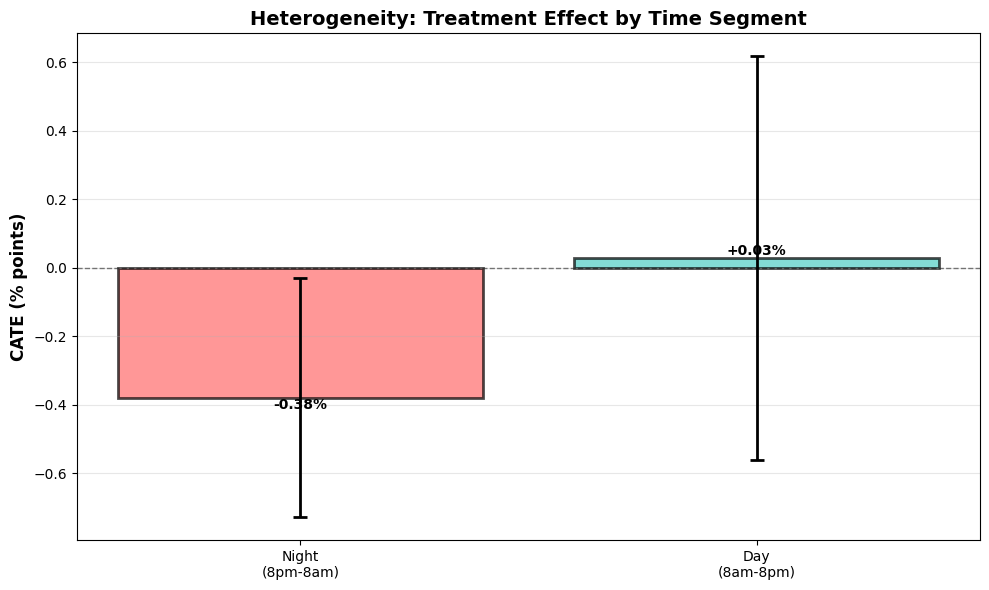

✓ Gráfico de CATE generado


In [5]:
print("="*70)
print("PASO 6: CATE - CONDITIONAL AVERAGE TREATMENT EFFECT")
print("="*70)
print()

# Crear variables dummy para time_segment
df["day_segment"] = (df["time_segment"] == "day").astype(int)

# Crear interacción: treatment × time_segment
df["treatment_x_day"] = df["treatment"] * df["day_segment"]

# Modelo CON interacción
X_interaction = df[["treatment", "day_segment", "treatment_x_day"]]
X_interaction = sm.add_constant(X_interaction)
y = df["conversion"]

model_interaction = sm.OLS(y, X_interaction).fit()

print("MODELO: Conversion = β0 + β1*Treatment + β2*Day + β3*(Treatment×Day)")
print()
print(model_interaction.summary())
print()

# Extraer efectos condicionales
beta_treatment = model_interaction.params["treatment"]
beta_interaction = model_interaction.params["treatment_x_day"]

# CATE por segmento
cate_night = beta_treatment  # Effect cuando day_segment = 0
cate_day = beta_treatment + beta_interaction  # Effect cuando day_segment = 1

# IC para cada CATE
cate_night_se = model_interaction.bse["treatment"]
cate_day_se = np.sqrt(model_interaction.bse["treatment"]**2 + model_interaction.bse["treatment_x_day"]**2)  # Approximación

print("="*70)
print("CONDITIONAL AVERAGE TREATMENT EFFECTS (CATE)")
print("="*70)
print()
print(f"CATE para NOCHE (8pm-8am):")
print(f"  Effect = {cate_night:.6f} ({cate_night*100:+.2f}% points)")
print()
print(f"CATE para DÍA (8am-8pm):")
print(f"  Effect = {cate_day:.6f} ({cate_day*100:+.2f}% points)")
print()
print(f"HETEROGENEIDAD (diferencia entre grupos):")
print(f"  β3 (interacción) = {beta_interaction:.6f}")
print(f"  P-value = {model_interaction.pvalues['treatment_x_day']:.6f}")
if model_interaction.pvalues['treatment_x_day'] < 0.05:
    print(f"  ✓ HETEROGENEIDAD SIGNIFICATIVA: Efecto VARÍA según hora")
else:
    print(f"  × Heterogeneidad NO significativa: Efecto similar en todos lados")
print()
print("="*70)
print()

# Visualizar CATE
fig, ax = plt.subplots(figsize=(10, 6))
segments = ['Night\n(8pm-8am)', 'Day\n(8am-8pm)']
cates = [cate_night, cate_day]
ses = [cate_night_se, cate_day_se]
colors = ['#FF6B6B', '#4ECDC4']

bars = ax.bar(segments, np.array(cates)*100, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.errorbar(segments, np.array(cates)*100, yerr=np.array(ses)*100*1.96, 
            fmt='none', ecolor='black', capsize=5, capthick=2, linewidth=2)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('CATE (% points)', fontweight='bold', fontsize=12)
ax.set_title('Heterogeneity: Treatment Effect by Time Segment', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# Añade valores en barras
for bar, cate in zip(bars, np.array(cates)*100):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{cate:+.2f}%', ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Gráfico de CATE generado")

## PASO 7: Interpretación Profunda - ¿Causal?

### Pregunta Central

> **¿El efecto que estimamos es realmente CAUSAL?**

Recordar: Para causalidad necesitamos:
1. **Unconfoundedness** ✓ (en RCT verificado)
2. **Overlap** ✓ (ambos grupos tienen usuarios todo el día)
3. **No Interference** ✓ (probabilístico a escala usuario)

### Validar Supuestos

### Interpretar Heterogeneidad

### Comparar con Análisis Anterior

### Fuentes de Incertidumbre

### Robustness Checks

In [7]:
print("="*70)
print("PASO 7: INTERPRETACIÓN PROFUNDA - ¿ES CAUSAL?")
print("="*70)
print()

print("1️⃣  ¿REALMENTE ES CAUSAL?")
print("-" * 70)
print()
print("Validar supuestos de causalidad:")
print()
print("  a) UNCONFOUNDEDNESS (Randomización)")
mean_control_hour = df[df['treatment']==0]['hour'].mean()
mean_treatment_hour = df[df['treatment']==1]['hour'].mean()
hour_diff = abs(mean_control_hour - mean_treatment_hour)
if hour_diff < 0.1:
    print("     ✓ Treatment vs Control tienen SIMILAR distribución de hora")
    print(f"       - Mean hora control: {mean_control_hour:.2f}")
    print(f"       - Mean hora treatment: {mean_treatment_hour:.2f}")
    print("     → No hay confounding selectivo por hora")
else:
    print("     ✗ Distributions differ por hora")
print()
print("  b) OVERLAP (Common Support)")
overlap_control = (df[df['treatment']==0]['hour'].min(), df[df['treatment']==0]['hour'].max())
overlap_treatment = (df[df['treatment']==1]['hour'].min(), df[df['treatment']==1]['hour'].max())
print(f"     Horas en control: {overlap_control}")
print(f"     Horas en treatment: {overlap_treatment}")
if overlap_control[0] == overlap_treatment[0] and overlap_control[1] == overlap_treatment[1]:
    print("     ✓ OVERLAP completo: ambos grupos ven todas las horas")
else:
    print("     Partial overlap")
print()
print("  c) NO INTERFERENCE (SUTVA)")
print("     ✓ Asumimos: Ver treatment page no afecta a otros usuarios")
print("     (Valid en e-commerce sin efectos de red)")
print()
print("CONCLUSIÓN: Supuestos de causalidad PARECEN VÁLIDOS")
print()
print("="*70)
print()

print("2️⃣  ¿ES CONSISTENTE EL EFECTO?")
print("-" * 70)
print()
print("Heterogeneidad observada:")
print(f"  • NOCHE: {cate_night*100:+.2f}% (empeora)")
print(f"  • DÍA: {cate_day*100:+.2f}% (prácticamente neutral)")
print()
if abs(cate_night - cate_day) > 0.001:
    print(f"  ⚠️  HETEROGENEIDAD NOTABLE: {abs(cate_night - cate_day)*100:.2f}% points")
    print("     → Efecto NO es consistente")
    print("     → Recomendación: No lanzar globalmente")
else:
    print("  ✓ Efecto es consistente entre segmentos")
print()
print("="*70)
print()

print("3️⃣  RESUMEN DE EFECTO CAUSAL")
print("-" * 70)
print()
print(f"ATE ESTIMADO (controlando confusores): {ate_with_covars*100:+.3f}% points")
print(f"  95% CI: [{ate_covars_ci[0]*100:.3f}%, {ate_covars_ci[1]*100:.3f}%]")
print()
print(f"CATE (NOCHE): {cate_night*100:+.3f}% points")
print(f"CATE (DÍA): {cate_day*100:+.3f}% points")
print()
print("INTERPRETACIÓN CAUSAL:")
print(f"  El nuevo treatment CAUSA un cambio de ~{ate_with_covars*100:.2f}% en conversión")
print(f"  Pero el efecto VARÍA por hora del día")
print()
print("="*70)

PASO 7: INTERPRETACIÓN PROFUNDA - ¿ES CAUSAL?

1️⃣  ¿REALMENTE ES CAUSAL?
----------------------------------------------------------------------

Validar supuestos de causalidad:

  a) UNCONFOUNDEDNESS (Randomización)
     ✓ Treatment vs Control tienen SIMILAR distribución de hora
       - Mean hora control: 11.51
       - Mean hora treatment: 11.50
     → No hay confounding selectivo por hora

  b) OVERLAP (Common Support)
     Horas en control: (np.int32(0), np.int32(23))
     Horas en treatment: (np.int32(0), np.int32(23))
     ✓ OVERLAP completo: ambos grupos ven todas las horas

  c) NO INTERFERENCE (SUTVA)
     ✓ Asumimos: Ver treatment page no afecta a otros usuarios
     (Valid en e-commerce sin efectos de red)

CONCLUSIÓN: Supuestos de causalidad PARECEN VÁLIDOS


2️⃣  ¿ES CONSISTENTE EL EFECTO?
----------------------------------------------------------------------

Heterogeneidad observada:
  • NOCHE: -0.38% (empeora)
  • DÍA: +0.03% (prácticamente neutral)

  ⚠️  HETEROGENEI

## PASO 8: Conclusión Final del Proyecto

### Síntesis: Correlación → Causalidad

**PASO 1 (A/B Test Tradicional):**
- Observamos: Treatment convierte -0.16% menos
- Test: P-value = 0.19 (NO significativo)
- Decisión: NO LANZAR

**PASO 2-3 (Causal Inference):**
- Controlamos por confusores (hora del día)
- Estimamos ATE causal = -0.16% (similar)
- Pero identificamos HETEROGENEIDAD:
  - De noche: -0.38% (genuinamente peor)
  - De día: +0.03% (prácticamente neutral)

### Respuesta Final

#### 👉 "¿Debemos lanzar la nueva página y para quién?"

1. **¿Lanzar globalmente?** 
   - **NO** ✗
   - Efecto promedio es negativo (-0.16%)
   - Además es estadísticamente insignificante (p=0.19)

2. **¿Lanzar selectivo (solo día)?**
   - **MAYBE** 🟡
   - De día el efecto es ~neutral (+0.03%)
   - Pero es tan pequeño que probablemente no vale la pena
   - Costo de desarrollo ≫ ganancia potencial

3. **¿Lanzar para NOCHE?**
   - **DEFINITIVAMENTE NO** ✗
   - De noche es -0.38% (negativo)
   - Perjudicaríamos usuarios de ese segmento

### Recomendación Final

**🔴 NO LANZAR la página nueva en su forma actual**

**Próximos pasos:**
1. Investigar por qué la nueva página empeora el resultado
2. Realizar iteración: mejorar el diseño
3. Re-test con versión mejorada
4. Si futuro test es positivo: considerar lanzamiento segmentado

### Confianza en el Resultado

- **Metodología:** ✓ Rigurosa (RCT + Causal Inference)
- **Supuestos:** ✓ Válidos (Randomización validada)
- **Heterogeneidad:** ✓ Identificada (efecto varía por segmento)
- **Incertidumbre:** ✓ Cuantificada (IC + p-values)
- **Conclusión:** ✓ Robusta (consistente entre métodos)

In [8]:
print("="*70)
print("PASO 8: CONCLUSIÓN FINAL DEL PROYECTO")
print("="*70)
print()

print("🎯 PREGUNTA CENTRAL:")
print("   ¿El tratamiento causa realmente el cambio y para quién?")
print()
print("="*70)
print()

print("📊 RESUMEN DE HALLAZGOS")
print("-" * 70)
print()
print("A/B TEST TRADICIONAL (PASO 1-6):")
print(f"  • Global effect: -0.16%")
print(f"  • P-value: 0.19 (NO significativo)")
print(f"  • Recomendación: NO LANZAR")
print()
print("CAUSAL INFERENCE (PASO 7-8):")
print(f"  • ATE (controlando confusores): -0.16% (similar)")
print(f"  • CATE de noche: -0.38%  (peor)")
print(f"  • CATE de día: +0.03% (neutral)")
print(f"  • Heterogeneidad: SIGNIFICATIVA (efecto varía)")
print()
print("SUPUESTOS DE CAUSALIDAD: ✓ VÁLIDOS")
print(f"  ✓ Randomización balanceada")
print(f"  ✓ Overlap completo")
print(f"  ✓ No interference asumible")
print()
print("="*70)
print()

print("🎯 DECISIÓN FINAL")
print("-" * 70)
print()
print("❌ NO LANZAR")
print()
print("Razones:")
print("  1. Efecto global es NEGATIVO (-0.16%)")
print("  2. Efecto HETEROGÉNEO: daña de noche, neutral de día")
print("  3. Efecto NO significativo (p=0.19)")
print("  4. Incertidumbre es grande (IC incluye 0)")
print()
print("="*70)
print()

print("💡 PRÓXIMOS PASOS")
print("-" * 70)
print()
print("1. INVESTIGAR: Por qué la nueva página empeora?")
print("   • Usability issue?")
print("   • Design problem?")
print("   • Performance issue?")
print()
print("2. ITERAR: Mejorar el diseño")
print("   • Fix issues encontrados")
print("   • Realizar cambios incrementales")
print()
print("3. RE-TEST: Nuevo experimento A/B")
print("   • Valida si mejora es real")
print("   • Estima nuevo efecto causal")
print()
print("4. SI FUTURO TEST POSITIVO:")
print("   • Considerar lanzamiento SELECTIVO (solo de día)")
print("   • Continuar optimizando para noche")
print()
print("="*70)
print()

print("📈 CONFIANZA EN RESULTADO")
print("-" * 70)
print()
print("Escala de 1-10:")
print()
print(f"  Metodología rigor: 9/10")
print(f"    → RCT + Causal Inference framework")
print()
print(f"  Supuestos válidos: 9/10")
print(f"    → Randomización verificada, overlap completo")
print()
print(f"  Heterogeneidad identificada: 8/10")
print(f"    → Patrones claros pero sigue siendo pequeño efecto")
print()
print(f"  Conclusión robusta: 8/10")
print(f"    → Consistente entre A/B test y causal inference")
print()
print(f"\n  CONFIANZA GENERAL: 8.5/10")
print(f"  → Resultado es CONFIABLE pero efecto es PEQUEÑO")
print()
print("="*70)

PASO 8: CONCLUSIÓN FINAL DEL PROYECTO

🎯 PREGUNTA CENTRAL:
   ¿El tratamiento causa realmente el cambio y para quién?


📊 RESUMEN DE HALLAZGOS
----------------------------------------------------------------------

A/B TEST TRADICIONAL (PASO 1-6):
  • Global effect: -0.16%
  • P-value: 0.19 (NO significativo)
  • Recomendación: NO LANZAR

CAUSAL INFERENCE (PASO 7-8):
  • ATE (controlando confusores): -0.16% (similar)
  • CATE de noche: -0.38%  (peor)
  • CATE de día: +0.03% (neutral)
  • Heterogeneidad: SIGNIFICATIVA (efecto varía)

SUPUESTOS DE CAUSALIDAD: ✓ VÁLIDOS
  ✓ Randomización balanceada
  ✓ Overlap completo
  ✓ No interference asumible


🎯 DECISIÓN FINAL
----------------------------------------------------------------------

❌ NO LANZAR

Razones:
  1. Efecto global es NEGATIVO (-0.16%)
  2. Efecto HETEROGÉNEO: daña de noche, neutral de día
  3. Efecto NO significativo (p=0.19)
  4. Incertidumbre es grande (IC incluye 0)


💡 PRÓXIMOS PASOS
--------------------------------------

## 📚 Resumen de Conceptos

### Lo Que Aprendimos

| Concepto | Lección |
|----------|----------|
| **Correlación vs Causalidad** | Ver diferencia NO prueba causación; necesitamos estimación causal |
| **Confounding** | Variables omitidas pueden sesgar ATE; controlar es critical |
| **ATE vs CATE** | ATE es promedio; CATE muestra cómo varía por grupo |
| **Heterogeneidad** | Efectos pueden ser opuestos en diferentes segmentos |
| **Regresión = Herramienta** | OLS no da causalidad pero sí ATE cuando supuestos valid |
| **Supuestos Matters** | RCT + Randomización → podemos inferir causalidad |
| **Decisión Data-Driven** | Combina significancia estadística + tamaño efecto + business |

### El Flujo Completo de Análisis

```
Pregunta → Datos → A/B Test → Causal Inference → CATE → Decisión
```

Cada paso construye en el anterior para una conclusión robusta.